# **Individual Analysis of Bipartite Networks**

# Import Libraries and Configurations

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import rpy2.robjects as ro
from networkx.algorithms import bipartite
from rpy2.robjects import conversion, pandas2ri
from rpy2.robjects.packages import importr

# Import R's bipartite package
bipartite_r = importr('bipartite')

# Add project root to Python's path
sys.path.append(os.path.abspath(os.path.join('..')))

from config import (
    DATA_SUBDIRS,
    NETWORK_DATA_DIRS,
    NETWORK_FILES,
)

# Remove the HER2-enriched group from the analysis
GROUPS = DATA_SUBDIRS.copy()
GROUPS.remove('her2-enriched')

# Define the possible types of bipartite networks
NETWORK_TYPES = ('interaction', 'membership')

# Metrics calculated in the individual analysis
METRICS = [
    # 'degree', 
    'betweenness_centrality', 
    'closeness_centrality', 
    'degree_centrality', 
    'redundancy_coefficient', 
]

/home/mylena-roberta/Unicamp/pan-cancer-analysis/venv/lib/python3.12/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "PWD" redefined by R and overriding existing variable. Current: "/home/mylena-roberta", R: "/home/mylena-roberta/Unicamp/pan-cancer-analysis/notebooks"
  warnings.warn(
/home/mylena-roberta/Unicamp/pan-cancer-analysis/venv/lib/python3.12/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "LD_LIBRARY_PATH" redefined by R and overriding existing variable. Current: "/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server", R: "/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server:/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server"
  warnings.warn(
/home/mylena-roberta/Unicamp/pan-cancer-analysis/venv/lib/python3.12/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_LIBS_SITE" redefined by R and overriding

# Functions

## Network Object

In [2]:
def create_bipartite_network(df_edges, df_nodes):
    # Create the network using an edge list
    B = nx.from_pandas_edgelist(
        df=df_edges,
        source='source',
        target='target',
        edge_attr=True,
    )

    # Assign partition attribute
    partitions = list(df_nodes['type'].unique())
    attr_dict = df_nodes.set_index('id')['type'].to_dict()
    nx.set_node_attributes(G=B, values=attr_dict, name='partition')

    # Define the partition sets
    partition1 = {
        n for n, d in B.nodes(data=True) 
        if d['partition'] == partitions[0]
    }
    partition2 = set(B) - partition1

    # Set the bipartite flag
    nx.set_node_attributes(
        G=B,
        values=(
            {n: 0 for n in partition1} 
            | {n: 1 for n in partition2}
        ),
        name='bipartite',
    )

    return B

## Topological Analysis

### Module Detection

#### Build the Biadjacency Matrix

In [3]:
def build_biadjacency_matrix(B):
    # Identify the two partitions
    rows = {
        n for n, d in B.nodes(data=True) 
        if d['bipartite'] == 0
    }
    cols = set(B) - rows

    # Sort the sets of rows and columns by the names of the nodes
    rows = sorted(rows)
    cols = sorted(cols)

    # Build the biadjacency matrix
    B_matrix = bipartite.biadjacency_matrix(
        B, row_order=rows, column_order=cols
    )

    # Transform the biadjacency matrix into a DataFrame
    df_matrix = pd.DataFrame(
        data=B_matrix.toarray(), index=rows, columns=cols
    )

    return df_matrix

#### Detect Modules Using R's `bipartite`

In [4]:
def detect_modules(B):
    # Represent the network as a biadjacency matrix
    df_matrix = build_biadjacency_matrix(B)

    # Convert the DataFrame matrix into a R numeric matrix
    with conversion.localconverter(
        ro.default_converter + pandas2ri.converter
    ):
        r_matrix = conversion.py2rpy(df_matrix)
    
    r_matrix = ro.r('as.matrix')(r_matrix)
    r_matrix = ro.r('matrix')(
        ro.r('as.numeric')(r_matrix),
        nrow=r_matrix.nrow,
        ncol=r_matrix.ncol,
    )

    # Run bipartite's computeModules()
    modules = bipartite_r.computeModules(
        web=r_matrix, 
        method='Beckett', # DormannStrauss or Beckett
        deep=False, 
        forceLPA=True,
    )

    # # Extract the modularity score
    # modularity = modules.do_slot('likelihood')[0]
    # print(f'Modularity (likelihood): {modularity:.4f}')

    # Extract module memberships
    modules_slot = modules.do_slot('modules')
    n_rows, n_cols = df_matrix.shape
    modules_vec = list(modules_slot)
    row_modules = modules_vec[:n_rows]
    col_modules = modules_vec[n_rows:n_rows + n_cols]

    # if 'list' in modules_slot.rclass:
    #     row_modules = list(modules_slot.rx2('row'))
    #     col_modules = list(modules_slot.rx2('col'))

    # Associate each node with the module to which it belongs
    row_modules = dict(zip(df_matrix.index, row_modules))
    col_modules = dict(zip(df_matrix.columns, col_modules))

    # Add the module membership as an attribute of the nodes
    nx.set_node_attributes(G=B, values=row_modules, name='module_id')
    nx.set_node_attributes(G=B, values=col_modules, name='module_id')

### Connected Components Detection

In [5]:
def detect_connected_components(B):
    # Sort the connected components in descending order of size
    components = nx.connected_components(B)
    ordered_components = sorted(components, key=len, reverse=True)

    # Relate each node to the connected component to which it belongs
    node_component = dict()
    for component_id, component in enumerate(ordered_components):
        for node in component:
            node_component[node] = component_id

    # Add the ID of the connected component as an attribute of the nodes
    nx.set_node_attributes(
        G=B, values=node_component, name='connected_component_id'
    )

    # Define the membership flag for the largest component nodes
    is_in_largest_component = {
        n: int(B.nodes[n]['connected_component_id'] == 0)
        for n in B.nodes
    }
    nx.set_node_attributes(
        G=B, values=is_in_largest_component, name='is_in_largest_component'
    )

### Degree Calculation

In [6]:
def compute_degree(B):
    # Define one of the partitions
    partition = [
        n for n, d in B.nodes(data=True) if d['bipartite'] == 0
    ]

    # Compute the degrees for each node partition
    degrees_a, degrees_b = bipartite.degrees(B=B, nodes=partition)

    # Combine the degree values ​​of each partition into a single dictionary
    degrees = dict(list(degrees_a) + list(degrees_b))

    # Add the degree value as an attribute of the nodes
    nx.set_node_attributes(G=B, values=degrees, name='degree')

### Centralities Calculation

#### Betweenness

In [7]:
def compute_betweenness_centrality(B, partition):
    # Compute the betweenness centrality of each node
    betweenness = bipartite.betweenness_centrality(
        G=B, nodes=partition
    )

    # Add the betweenness centrality value as an attribute of the nodes
    nx.set_node_attributes(
        G=B, values=betweenness, name='betweenness_centrality'
    )

#### Closeness

In [8]:
def compute_closeness_centrality(B, partition):
    # Compute the closeness centrality of each node
    closeness = bipartite.closeness_centrality(
        G=B, nodes=partition, normalized=True
    )

    # Add the closeness centrality value as an attribute of the nodes
    nx.set_node_attributes(
        G=B, values=closeness, name='closeness_centrality'
    )

#### Degree

In [9]:
def compute_degree_centrality(B, partition):
    # Compute the degree centrality of each node
    degree = bipartite.degree_centrality(
        G=B, nodes=partition
    )

    # Add the degree centrality value as an attribute of the nodes
    nx.set_node_attributes(
        G=B, values=degree, name='degree_centrality'
    )

### Redundancy Calculation

In [10]:
def compute_redundancy(B, partition_a, partition_b):
    # Select the valid nodes for the calculation
    valid_partition_a = [n for n in partition_a if B.degree(n) >= 2]
    valid_partition_b = [n for n in partition_b if B.degree(n) >= 2]
    valid_nodes = valid_partition_a + valid_partition_b
    
    # Compute the redundancy coefficient of each valid node
    redundancy = bipartite.node_redundancy(G=B, nodes=valid_nodes)

    # Add the redundancy coefficient value as an attribute of the nodes
    nx.set_node_attributes(
        G=B, values=redundancy, name='redundancy_coefficient'
    )

### Compute Metrics

In [11]:
def compute_metrics(B):
    # Detects modules respecting the bipartite structure
    detect_modules(B)
    
    # Identify the connected components of the network
    detect_connected_components(B)

    # # Compute the degree of all nodes
    # compute_degree(B)

    # Select the subnetwork that represent the largest component
    largest_cc_nodes = [
        n for n, d in B.nodes(data=True) 
        if d['connected_component_id'] == 0
    ]
    B_largest_cc = B.subgraph(largest_cc_nodes)

    # Define the partitions of the largest component
    largest_cc_partition1 = {
        n for n, d in B_largest_cc.nodes(data=True) 
        if d['bipartite'] == 0
    }
    largest_cc_partition2 = set(B_largest_cc) - largest_cc_partition1
    
    # Compute the centrality measures for the largest component nodes
    compute_betweenness_centrality(B_largest_cc, largest_cc_partition1)
    compute_closeness_centrality(B_largest_cc, largest_cc_partition1)
    compute_degree_centrality(B_largest_cc, largest_cc_partition1)
    
    # Compute the redundancy for the valid largest component nodes
    compute_redundancy(
        B_largest_cc, largest_cc_partition1, largest_cc_partition2
    )

    # Store the node attributes in a DataFrame
    nodes = dict(B.nodes(data=True))
    df_metrics = pd.DataFrame.from_dict(data=nodes, orient='index') \
        .reset_index() \
        .drop(columns=['bipartite', 'partition']) \
        .rename(columns={'index': 'id'})

    return df_metrics

## Analysis Report

### Plot Biadjacency Matrix

In [12]:
def plot_biadjacency_matrix(df_edges, df_nodes):
    # Identify the nodes in the two partitions
    partition1, partition2 = df_nodes['type'].unique()
    rows = df_nodes.query('type == @partition1') \
        ['id'].to_list()
    cols = df_nodes.query('type == @partition2') \
        ['id'].to_list()

    # Build the biadjacency matrix
    B = df_edges \
        .assign(value=1) \
        .pivot_table(
            index='source',
            columns='target',
            values='value',
            aggfunc='max',
            fill_value=0,
        ) \
        .reindex(index=rows, columns=cols, fill_value=0)

    # Plot the matrix as an image
    plt.figure(figsize=(16,8))
    plt.imshow(X=B.values, aspect='auto', cmap='binary')
    plt.title('Biadjacency Matrix')
    plt.xlabel(f'{partition1} Nodes')
    plt.ylabel(f'{partition2} Nodes')
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
    plt.show()

### Global Report

In [13]:
def global_report(df_edges, df_nodes):
    # Print the number of edges
    num_edges = df_edges.shape[0]
    print(f'> number of edges = {num_edges}')

    # Print the number of nodes
    num_nodes = df_nodes.shape[0]
    print(f'\n> number of nodes ({num_nodes}):')

    # Print the number of nodes per partition
    part_nodes = list()
    for part in df_nodes['type'].unique():
        part_num_nodes = df_nodes \
            .query('type == @part') \
            .shape[0]
        
        part_nodes.append(part_num_nodes)
        part_frac = (part_num_nodes / num_nodes) * 100
        print(
            f'- {part}s = {part_num_nodes} '
            + f'({round(part_frac, 2)}%)'
        )

    # Print the network density
    density = num_edges / (part_nodes[0] * part_nodes[1])
    print(f'\n> network density = {round(density, 2)}')

    # Print the number of connected components
    num_cc = df_nodes['connected_component_id'].nunique()
    print(f'\n> number of connected components = {num_cc}')

    # Print the number of nodes in the largest component
    largest_cc_num_nodes = df_nodes \
        .query('is_in_largest_component == 1') \
        .shape[0]
    largest_cc_nodes_frac = \
        (largest_cc_num_nodes / num_nodes) * 100
    print(
        f'> number of nodes in the largest component = '
        + f'{largest_cc_num_nodes} '
        + f'({round(largest_cc_nodes_frac, 2)}%)'
    )
    
    # Print the number of nodes per module
    nodes_per_module = df_nodes \
        .value_counts(subset='module_id') \
        .reset_index()
    print(f'\n> nodes per module: \n{nodes_per_module}')

    # Plot the biadjacency matrix of the network
    plot_biadjacency_matrix(df_edges, df_nodes)

### Print the Description of the Metric Values

In [14]:
def print_metric_values_description(df_metrics, metric, nodes_to_rank=5):
    # Print the name of the metric as a title
    metric_name = metric.replace('_', ' ')
    print(f'\n##### {metric_name.title()} #####\n')

    # Sort the nodes according to the parameters
    df_sorted = df_metrics \
        .sort_values(by=metric, ascending=False) \
        .dropna(subset=metric) \
        .reset_index(drop=True) \
        [['label', metric]]
    
    # Print the descriptive statistics
    print(f'> descriptive statistics: \n{df_sorted.describe()}')
    
    # Print the top and bottom ranked nodes
    for rank in ['top', 'bottom']:
        if rank == 'top':
            df_nodes = df_sorted.head(nodes_to_rank)
        else:
            df_nodes = df_sorted.tail(nodes_to_rank)

        print(
            f'\n> {rank}-{nodes_to_rank} nodes in '
            + f'descending order: \n{df_nodes}'
        )

### Partition Report

In [15]:
def partition_report(partition, df_nodes):
    # Select the partition nodes
    df_partition = df_nodes.query('type == @partition')
    print(f'===== {partition}s =====\n')

    # Print the number of nodes
    num_nodes = df_partition.shape[0]
    print(f'> number of nodes = {num_nodes}')

    # Print the number of nodes in the largest component
    largest_cc_nodes = df_partition \
        .query('is_in_largest_component == 1') \
        .shape[0]
    largest_cc_nodes_frac = \
        (largest_cc_nodes / num_nodes) * 100
    print(
        f'> number of nodes in the largest component ' 
        + f'= {largest_cc_nodes} ' 
        + f'({round(largest_cc_nodes_frac, 2)}%)'
    )

    # Print the description of the metric values
    for metric in METRICS:
        print_metric_values_description(
            df_metrics=df_partition,
            metric=metric,
        )

## Individual Network Analysis

In [16]:
def individual_analysis(group, network_type):
    # Define the path to the directory related to the group
    group_dir = (group.lower()).replace(' ', '-')
    dir_path = NETWORK_DATA_DIRS['processed'][group_dir]

    if network_type == 'interaction':
        # Interaction network: microRNA-mRNA network analysis
        edges_file = NETWORK_FILES['interaction-edges']
        nodes_file = NETWORK_FILES['interaction-nodes']
    elif network_type == 'membership':
        # Membership network: mRNA-pathway network analysis
        edges_file = 'membership-network-edges.csv'
        nodes_file = 'membership-network-nodes.csv'
    
    # Create DataFrames to represent the network
    df_edges = pd.read_csv(os.path.join(dir_path, edges_file))
    df_nodes = pd.read_csv(os.path.join(dir_path, nodes_file))

    # Create the network object
    B = create_bipartite_network(df_edges, df_nodes)

    # Perform the topological analysis of the network
    df_metrics = compute_metrics(B)

    # Add the metric values in the node's DataFrame
    df_nodes = pd.merge(
        left=df_nodes, right=df_metrics, how='left', on='id'
    )

    # Store the DataFrame of nodes with metric values
    file_name = f'{nodes_file.replace('.csv', '')}-with-metrics.csv'
    df_nodes.to_csv(os.path.join(dir_path, file_name), index=False)

    return df_edges, df_nodes

# Analyze the Networks

In [17]:
# Create a dictionary to store DataFrames related to network analysis
analyzed_networks = dict()

# Iterate over the network types
for network_type in NETWORK_TYPES:
    # Create empty DataFrames to store all edges and nodes
    df_all_edges = pd.DataFrame()
    df_all_nodes = pd.DataFrame()

    # Iterate over the possible groups
    for group in GROUPS:    
        # Perform individual network analysis
        df_edges, df_nodes = \
            individual_analysis(group, network_type)

        # Add group name column
        df_edges['group'] = group
        df_nodes['group'] = group
        
        # Concatenate the edges and nodes of the group to the others
        df_all_edges = pd.concat(
            objs=[df_all_edges, df_edges], ignore_index=True
        )
        df_all_nodes = pd.concat(
            objs=[df_all_nodes, df_nodes], ignore_index=True
        )
        
    # Store the edges and nodes related to the iterated network type
    analyzed_networks[network_type] = dict()
    analyzed_networks[network_type]['edges'] = df_all_edges.copy()
    analyzed_networks[network_type]['nodes'] = df_all_nodes.copy()

# Basal-like

In [18]:
# Define the group name
group = 'basal-like'

## Interaction Network

In [19]:
# Define the network type and the DataFrames associated with it
network_type = 'interaction'
df_edges = analyzed_networks[network_type]['edges'] \
    .query('group == @group')
df_nodes = analyzed_networks[network_type]['nodes'] \
    .query('group == @group')

> number of edges = 296

> number of nodes (291):
- MicroRNAs = 58 (19.93%)
- Messenger RNAs = 233 (80.07%)

> network density = 0.02

> number of connected components = 33
> number of nodes in the largest component = 171 (58.76%)

> nodes per module: 
   module_id  count
0        0.0    225
1        1.0     60
2        2.0      2
3        3.0      2
4        4.0      2


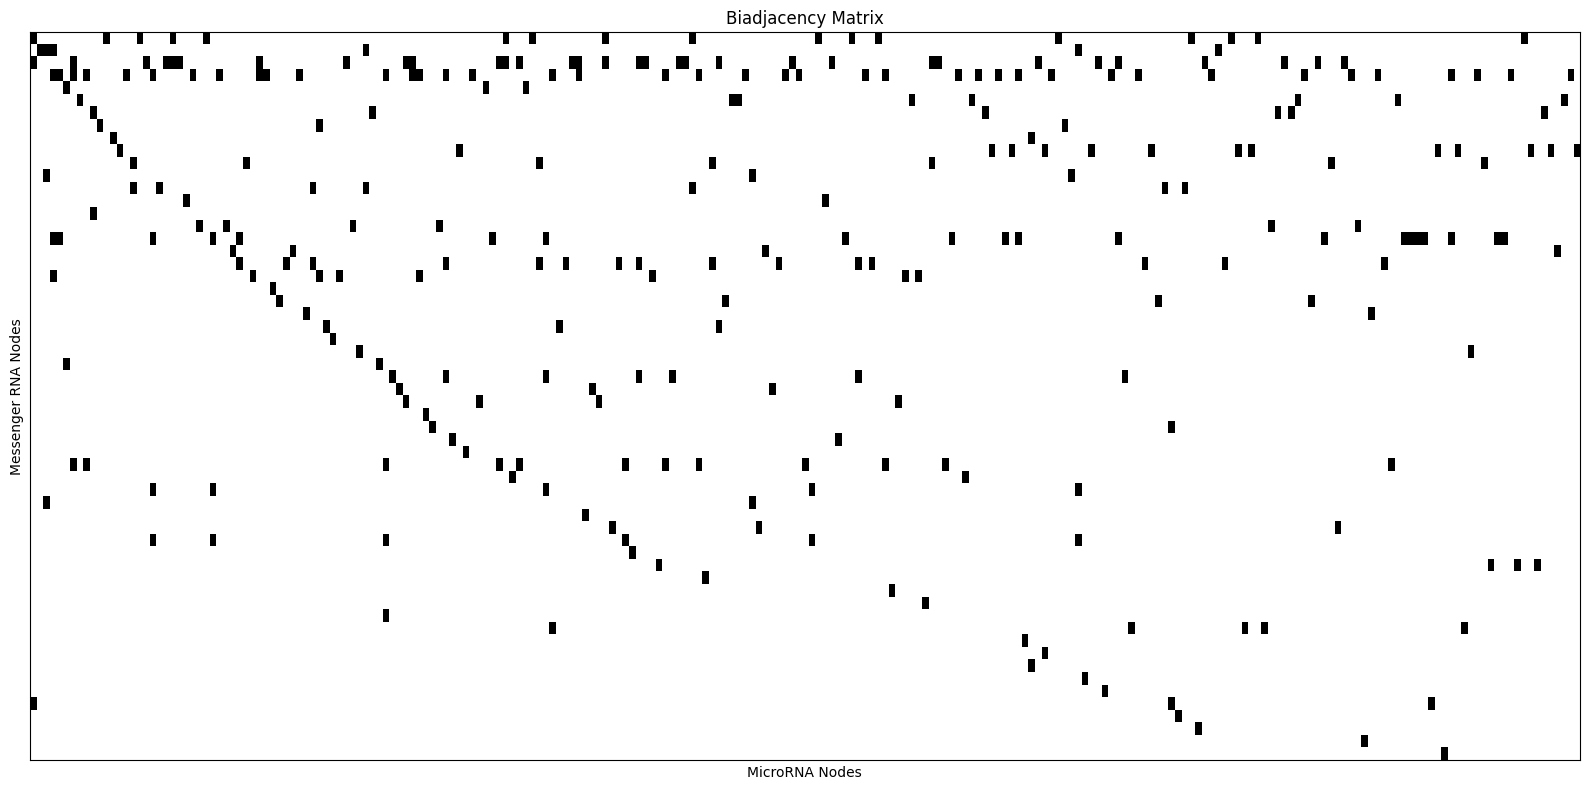

In [20]:
# Print the global network analysis report
global_report(df_edges, df_nodes)

In [21]:
# Print the analysis report for one of the network partitions
partition_report('MicroRNA', df_nodes)

===== MicroRNAs =====

> number of nodes = 58
> number of nodes in the largest component = 22 (37.93%)

##### Betweenness Centrality #####

> descriptive statistics: 
       betweenness_centrality
count               22.000000
mean                 0.098179
std                  0.138186
min                  0.000000
25%                  0.020574
50%                  0.047024
75%                  0.106675
max                  0.497522

> top-5 nodes in descending order: 
             label  betweenness_centrality
0    hsa-miR-96-5p                0.497522
1  hsa-miR-106b-5p                0.491275
2  hsa-miR-106a-5p                0.182827
3   hsa-miR-182-5p                0.156133
4  hsa-miR-200b-3p                0.152077

> bottom-5 nodes in descending order: 
              label  betweenness_centrality
17   hsa-miR-19a-3p                0.017603
18   hsa-miR-27a-3p                0.011782
19    hsa-miR-17-5p                0.011150
20   hsa-miR-19b-3p                0.005821
21  hsa-

In [22]:
# Print the analysis report for one of the network partitions
partition_report('Messenger RNA', df_nodes)

===== Messenger RNAs =====

> number of nodes = 233
> number of nodes in the largest component = 149 (63.95%)

##### Betweenness Centrality #####

> descriptive statistics: 
       betweenness_centrality
count              149.000000
mean                 0.009824
std                  0.022861
min                  0.000000
25%                  0.000000
50%                  0.000000
75%                  0.005118
max                  0.164538

> top-5 nodes in descending order: 
    label  betweenness_centrality
0   ATXN1                0.164538
1  RAB27A                0.093546
2    BNC2                0.083622
3    ZEB1                0.072088
4   CCND2                0.071987

> bottom-5 nodes in descending order: 
       label  betweenness_centrality
144  TMEM50B                     0.0
145   FNDC3A                     0.0
146   CAMTA2                     0.0
147    HDAC9                     0.0
148   TGFBR2                     0.0

##### Closeness Centrality #####

> descriptive stat

## Membership Network

In [23]:
# Define the network type and the DataFrames associated with it
network_type = 'membership'
df_edges = analyzed_networks[network_type]['edges'] \
    .query('group == @group')
df_nodes = analyzed_networks[network_type]['nodes'] \
    .query('group == @group')

> number of edges = 117

> number of nodes (59):
- Messenger RNAs = 46 (77.97%)
- Pathways = 13 (22.03%)

> network density = 0.2

> number of connected components = 1
> number of nodes in the largest component = 59 (100.0%)

> nodes per module: 
   module_id  count
0        0.0     40
1        1.0     14
2        2.0      2
3        3.0      2
4        4.0      1


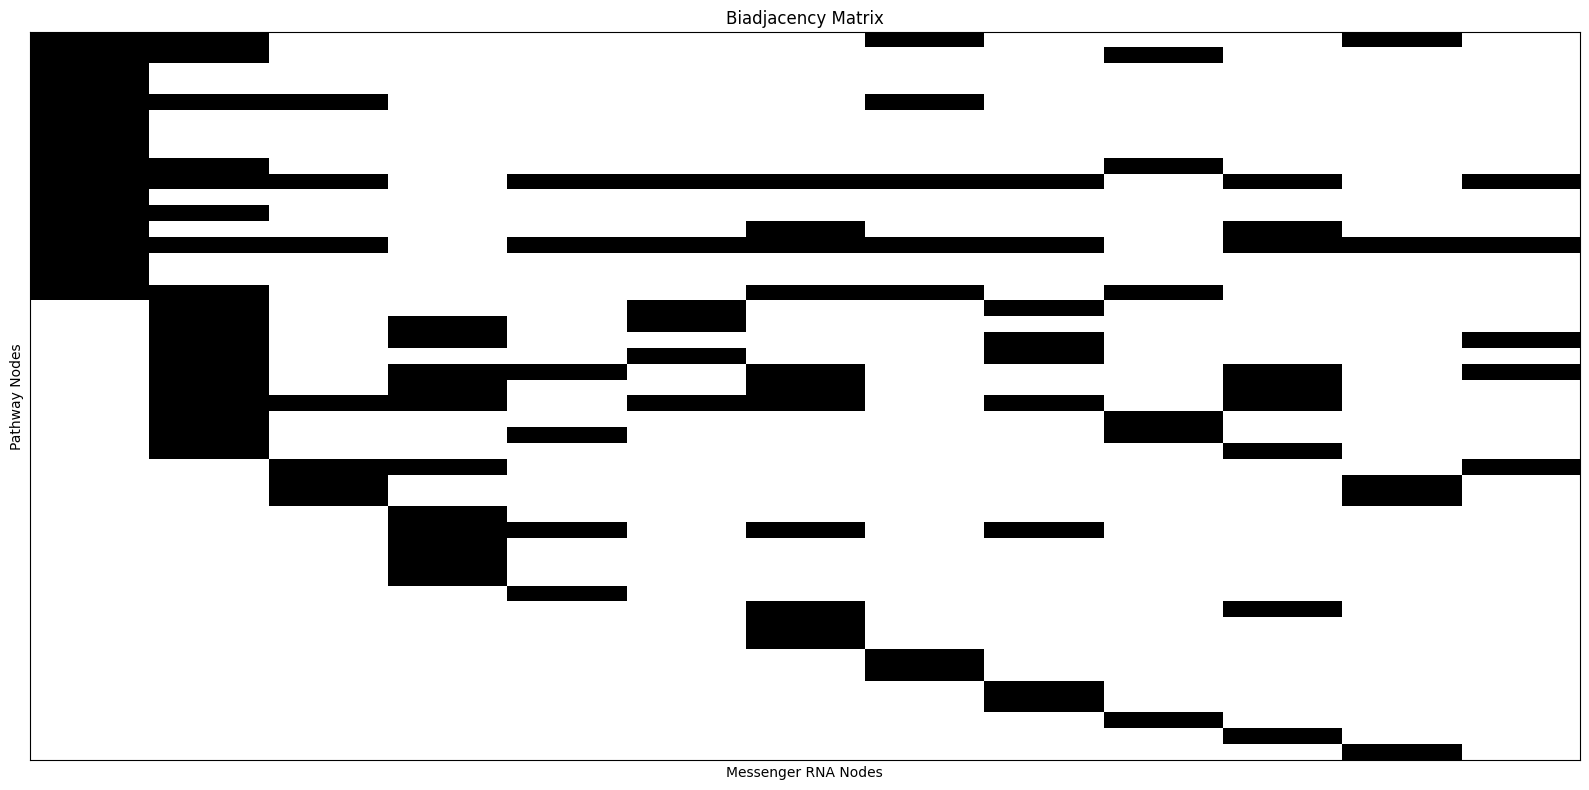

In [24]:
# Print the global network analysis report
global_report(df_edges, df_nodes)

In [25]:
# Print the analysis report for one of the network partitions
partition_report('Messenger RNA', df_nodes)

===== Messenger RNAs =====

> number of nodes = 46
> number of nodes in the largest component = 46 (100.0%)

##### Betweenness Centrality #####

> descriptive statistics: 
       betweenness_centrality
count               46.000000
mean                 0.018095
std                  0.040042
min                  0.000000
25%                  0.000000
50%                  0.001255
75%                  0.019429
max                  0.213343

> top-5 nodes in descending order: 
     label  betweenness_centrality
0  CD200R1                0.213343
1   CCDC50                0.152677
2    CHST1                0.074925
3  B4GALT5                0.060863
4     AFF1                0.050956

> bottom-5 nodes in descending order: 
    label  betweenness_centrality
41    MSN                     0.0
42   RXRA                     0.0
43  ELFN2                     0.0
44  NOVA1                     0.0
45  SESN3                     0.0

##### Closeness Centrality #####

> descriptive statistics: 
     

In [26]:
# Print the analysis report for one of the network partitions
partition_report('Pathway', df_nodes)

===== Pathways =====

> number of nodes = 13
> number of nodes in the largest component = 13 (100.0%)

##### Betweenness Centrality #####

> descriptive statistics: 
       betweenness_centrality
count               13.000000
mean                 0.105377
std                  0.088909
min                  0.019538
25%                  0.053902
50%                  0.077464
75%                  0.131449
max                  0.303593

> top-5 nodes in descending order: 
                                     label  betweenness_centrality
0  Transcriptional misregulation in cancer                0.303593
1                       Pathways in cancer                0.266365
2                Calcium signaling pathway                0.154318
3                   MAPK signaling pathway                0.131449
4                  Proteoglycans in cancer                0.097448

> bottom-5 nodes in descending order: 
                                        label  betweenness_centrality
8              

# Luminal A

In [27]:
# Define the group name
group = 'luminal-a'

## Interaction Network

In [28]:
# Define the network type and the DataFrames associated with it
network_type = 'interaction'
df_edges = analyzed_networks[network_type]['edges'] \
    .query('group == @group')
df_nodes = analyzed_networks[network_type]['nodes'] \
    .query('group == @group')

> number of edges = 259

> number of nodes (251):
- MicroRNAs = 44 (17.53%)
- Messenger RNAs = 207 (82.47%)

> network density = 0.03

> number of connected components = 22
> number of nodes in the largest component = 198 (78.88%)

> nodes per module: 
   module_id  count
0        0.0    198
1        1.0     47
2        2.0      2
3        3.0      2
4        4.0      2


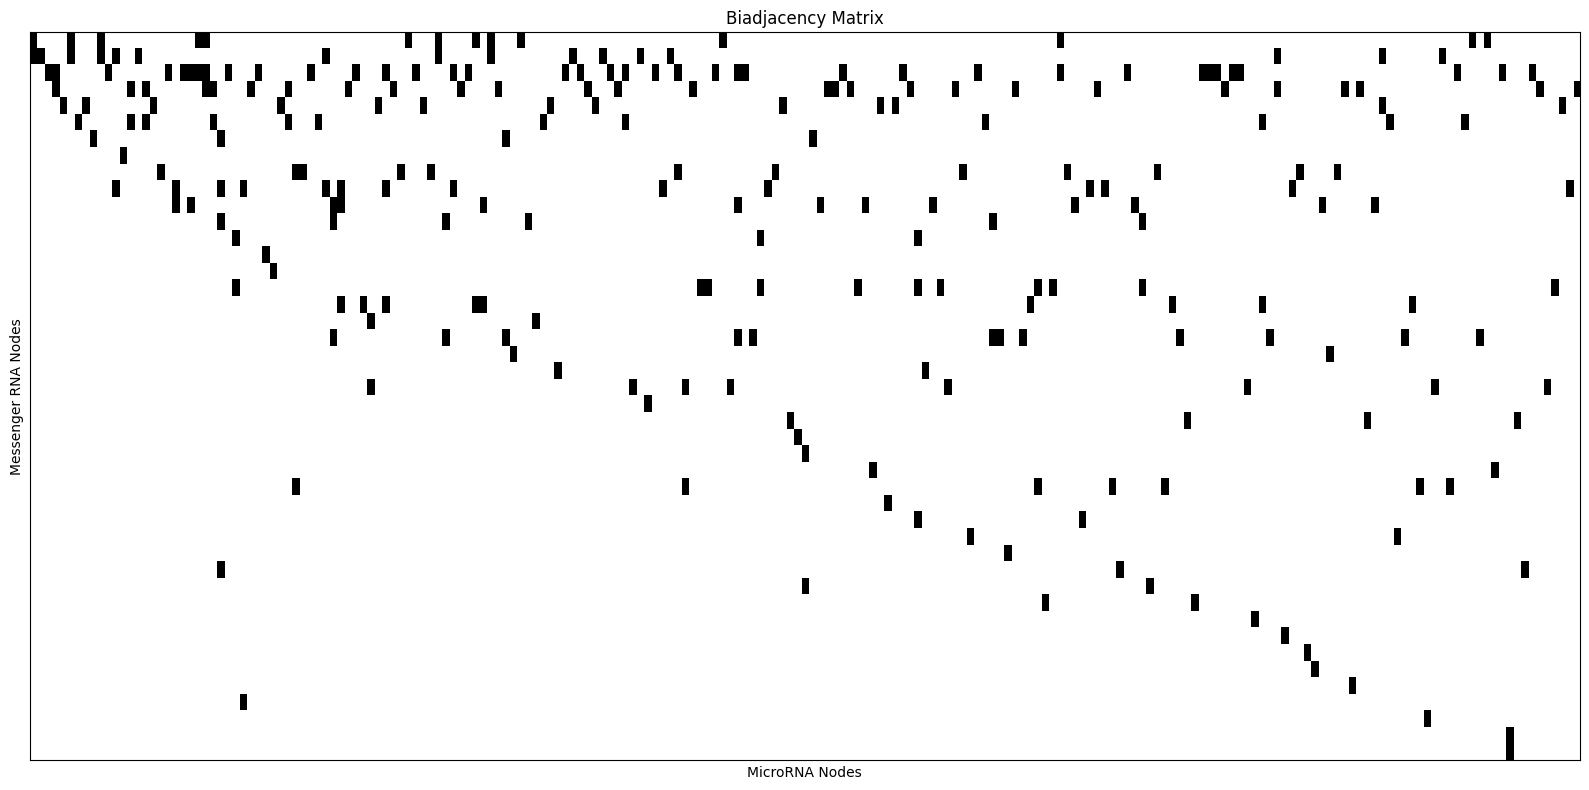

In [29]:
# Print the global network analysis report
global_report(df_edges, df_nodes)

In [30]:
# Print the analysis report for one of the network partitions
partition_report('MicroRNA', df_nodes)

===== MicroRNAs =====

> number of nodes = 44
> number of nodes in the largest component = 21 (47.73%)

##### Betweenness Centrality #####

> descriptive statistics: 
       betweenness_centrality
count               21.000000
mean                 0.131272
std                  0.128082
min                  0.000000
25%                  0.024279
50%                  0.115648
75%                  0.164148
max                  0.564774

> top-5 nodes in descending order: 
             label  betweenness_centrality
0    hsa-miR-96-5p                0.564774
1   hsa-miR-29b-3p                0.242159
2  hsa-miR-200b-3p                0.234775
3   hsa-miR-141-3p                0.232485
4  hsa-miR-301a-3p                0.222737

> bottom-5 nodes in descending order: 
              label  betweenness_centrality
16  hsa-miR-148b-3p                0.020274
17   hsa-miR-92a-3p                0.010163
18   hsa-miR-192-5p                0.010163
19   hsa-miR-20a-5p                0.000181
20  hsa-

In [31]:
# Print the analysis report for one of the network partitions
partition_report('Messenger RNA', df_nodes)

===== Messenger RNAs =====

> number of nodes = 207
> number of nodes in the largest component = 177 (85.51%)

##### Betweenness Centrality #####

> descriptive statistics: 
       betweenness_centrality
count              177.000000
mean                 0.011557
std                  0.032185
min                  0.000000
25%                  0.000000
50%                  0.000000
75%                  0.000000
max                  0.218683

> top-5 nodes in descending order: 
     label  betweenness_centrality
0     EBF3                0.218683
1   PXYLP1                0.139343
2  RUNX1T1                0.133915
3     CROT                0.131355
4    BACH2                0.131239

> bottom-5 nodes in descending order: 
         label  betweenness_centrality
172      LUZP1                     0.0
173     CYBRD1                     0.0
174      TBX15                     0.0
175    SLC24A4                     0.0
176  KIAA1549L                     0.0

##### Closeness Centrality #####



## Membership Network

In [32]:
# Define the network type and the DataFrames associated with it
network_type = 'membership'
df_edges = analyzed_networks[network_type]['edges'] \
    .query('group == @group')
df_nodes = analyzed_networks[network_type]['nodes'] \
    .query('group == @group')

> number of edges = 50

> number of nodes (34):
- Messenger RNAs = 29 (85.29%)
- Pathways = 5 (14.71%)

> network density = 0.34

> number of connected components = 1
> number of nodes in the largest component = 34 (100.0%)

> nodes per module: 
   module_id  count
0        0.0     19
1        1.0      9
2        2.0      2
3        3.0      2
4        4.0      2


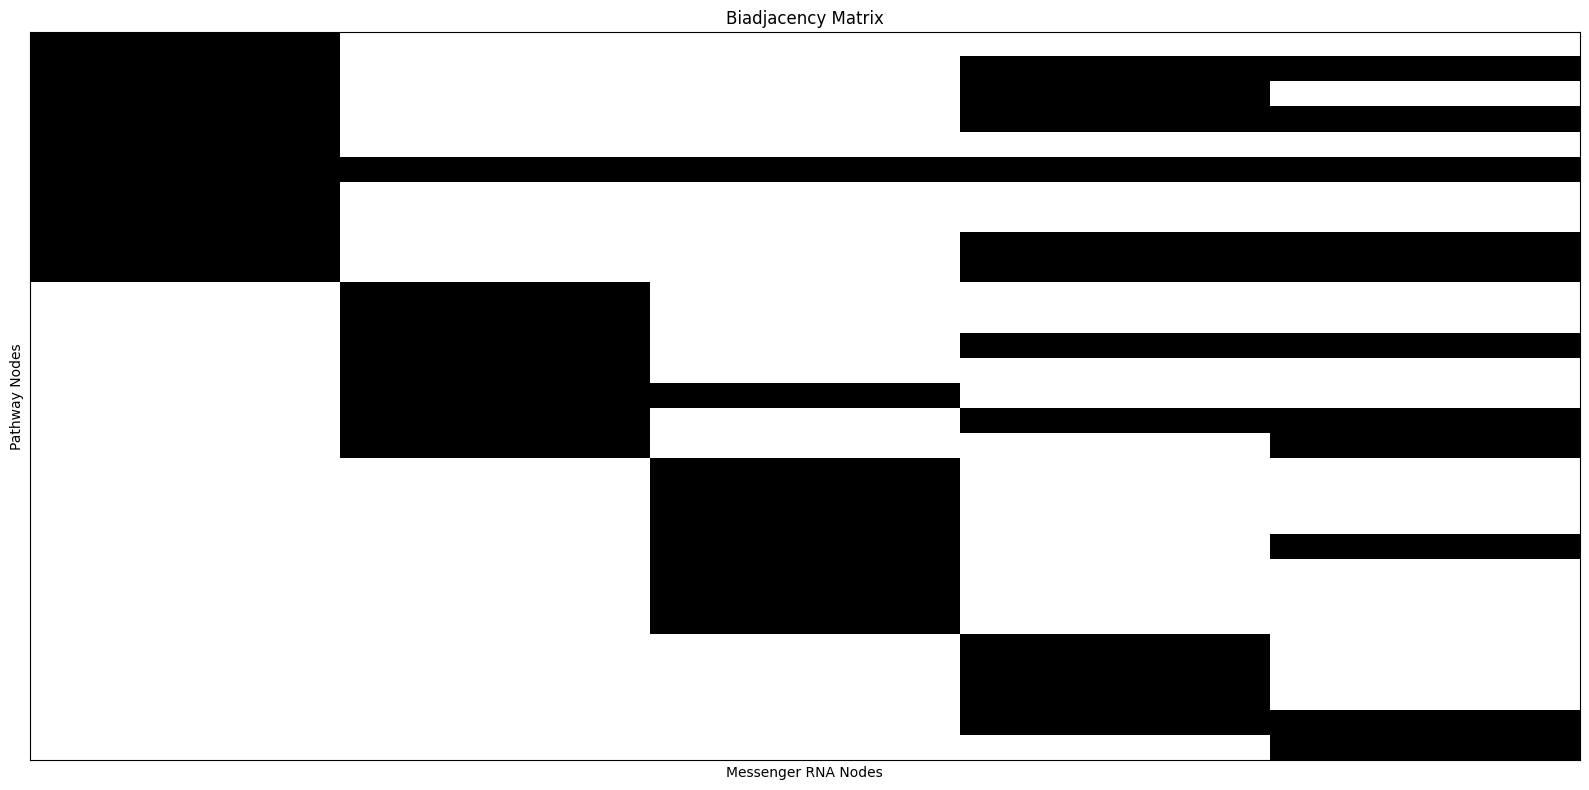

In [33]:
# Print the global network analysis report
global_report(df_edges, df_nodes)

In [34]:
# Print the analysis report for one of the network partitions
partition_report('Messenger RNA', df_nodes)

===== Messenger RNAs =====

> number of nodes = 29
> number of nodes in the largest component = 29 (100.0%)

##### Betweenness Centrality #####

> descriptive statistics: 
       betweenness_centrality
count               29.000000
mean                 0.026318
std                  0.081846
min                  0.000000
25%                  0.000000
50%                  0.000000
75%                  0.027454
max                  0.442784

> top-5 nodes in descending order: 
   label  betweenness_centrality
0   TCF4                0.442784
1  HMCN1                0.049770
2  ITGA9                0.044176
3    MAF                0.043723
4   TBX3                0.043723

> bottom-5 nodes in descending order: 
      label  betweenness_centrality
24     FRZB                     0.0
25      KIT                     0.0
26   EIF4E2                     0.0
27     ETS1                     0.0
28  TBC1D12                     0.0

##### Closeness Centrality #####

> descriptive statistics: 
     

In [35]:
# Print the analysis report for one of the network partitions
partition_report('Pathway', df_nodes)

===== Pathways =====

> number of nodes = 5
> number of nodes in the largest component = 5 (100.0%)

##### Betweenness Centrality #####

> descriptive statistics: 
       betweenness_centrality
count                5.000000
mean                 0.277863
std                  0.050369
min                  0.232747
25%                  0.238590
50%                  0.274533
75%                  0.284897
max                  0.358545

> top-5 nodes in descending order: 
                                     label  betweenness_centrality
0  Transcriptional misregulation in cancer                0.358545
1               PI3K-Akt signaling pathway                0.284897
2                           Focal adhesion                0.274533
3           Human papillomavirus infection                0.238590
4                  Hippo signaling pathway                0.232747

> bottom-5 nodes in descending order: 
                                     label  betweenness_centrality
0  Transcriptional m

# Luminal B

In [36]:
# Define the group name
group = 'luminal-b'

## Interaction Network

In [37]:
# Define the network type and the DataFrames associated with it
network_type = 'interaction'
df_edges = analyzed_networks[network_type]['edges'] \
    .query('group == @group')
df_nodes = analyzed_networks[network_type]['nodes'] \
    .query('group == @group')

> number of edges = 584

> number of nodes (559):
- MicroRNAs = 105 (18.78%)
- Messenger RNAs = 454 (81.22%)

> network density = 0.01

> number of connected components = 38
> number of nodes in the largest component = 464 (83.01%)

> nodes per module: 
   module_id  count
0        0.0    446
1        1.0    107
2        2.0      2
3        3.0      2
4        4.0      2


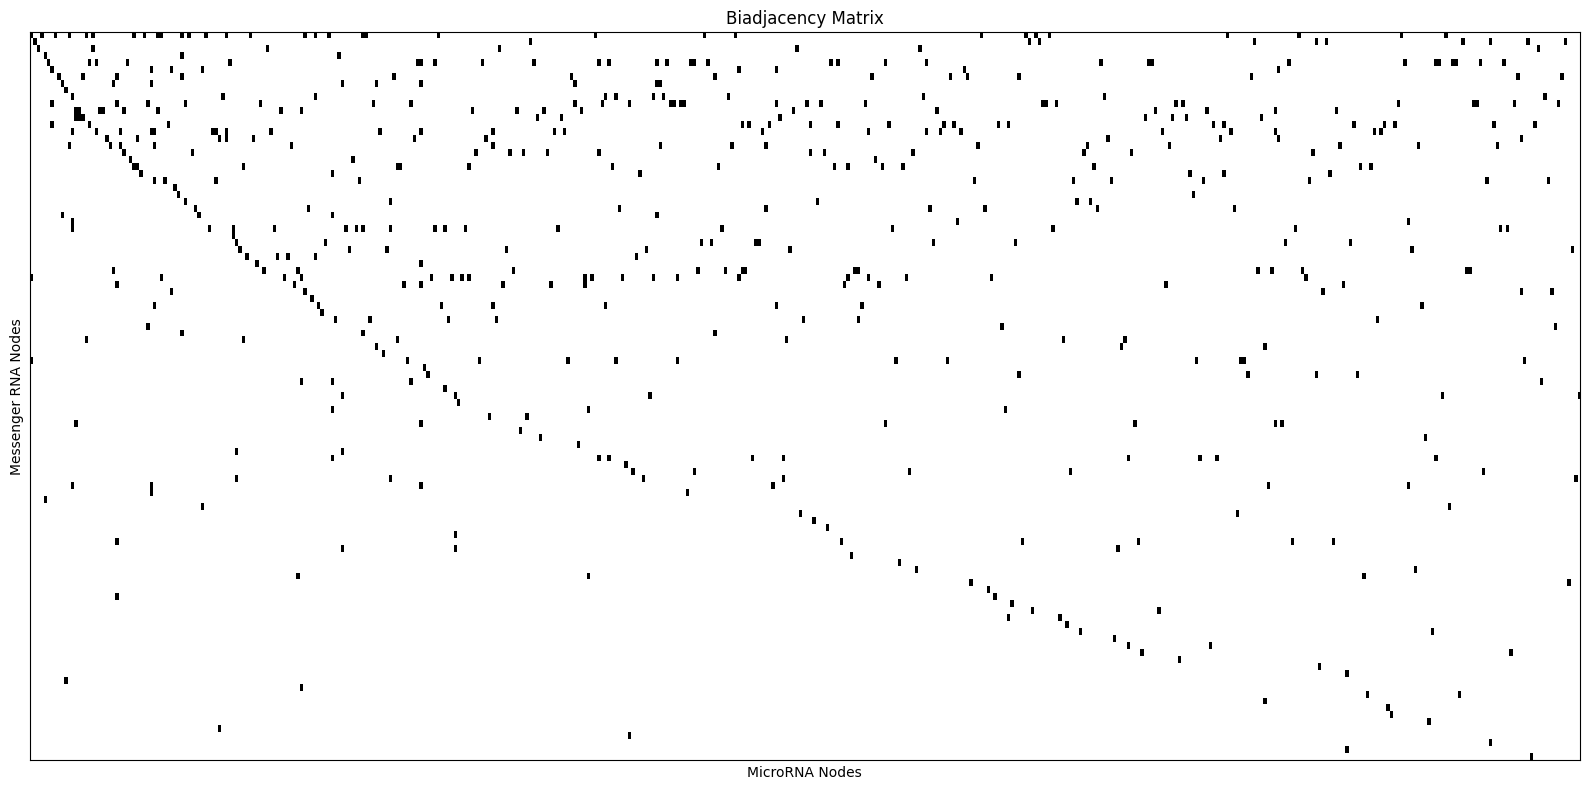

In [38]:
# Print the global network analysis report
global_report(df_edges, df_nodes)

In [39]:
# Print the analysis report for one of the network partitions
partition_report('MicroRNA', df_nodes)

===== MicroRNAs =====

> number of nodes = 105
> number of nodes in the largest component = 66 (62.86%)

##### Betweenness Centrality #####

> descriptive statistics: 
       betweenness_centrality
count               66.000000
mean                 0.045449
std                  0.057569
min                  0.000000
25%                  0.006429
50%                  0.024577
75%                  0.050019
max                  0.251333

> top-5 nodes in descending order: 
             label  betweenness_centrality
0  hsa-miR-200c-3p                0.251333
1  hsa-miR-106b-5p                0.234669
2   hsa-miR-27b-3p                0.196048
3   hsa-miR-18a-5p                0.174641
4   hsa-miR-33a-5p                0.167084

> bottom-5 nodes in descending order: 
              label  betweenness_centrality
61      hsa-miR-107                     0.0
62   hsa-miR-26b-5p                     0.0
63  hsa-miR-200a-3p                     0.0
64  hsa-miR-374b-5p                     0.0
65    h

In [40]:
# Print the analysis report for one of the network partitions
partition_report('Messenger RNA', df_nodes)

===== Messenger RNAs =====

> number of nodes = 454
> number of nodes in the largest component = 398 (87.67%)

##### Betweenness Centrality #####

> descriptive statistics: 
       betweenness_centrality
count              398.000000
mean                 0.005802
std                  0.016872
min                  0.000000
25%                  0.000000
50%                  0.000000
75%                  0.000000
max                  0.166059

> top-5 nodes in descending order: 
    label  betweenness_centrality
0  ZBTB20                0.166059
1  MAP4K4                0.127483
2   PEAK1                0.089503
3   KLF12                0.085418
4    EOGT                0.071826

> bottom-5 nodes in descending order: 
      label  betweenness_centrality
393  ZSWIM4                     0.0
394    NAV2                     0.0
395  TSPAN2                     0.0
396   SPSB4                     0.0
397    NAV3                     0.0

##### Closeness Centrality #####

> descriptive statistics

## Membership Network

In [41]:
# Define the network type and the DataFrames associated with it
network_type = 'membership'
df_edges = analyzed_networks[network_type]['edges'] \
    .query('group == @group')
df_nodes = analyzed_networks[network_type]['nodes'] \
    .query('group == @group')

> number of edges = 393

> number of nodes (140):
- Messenger RNAs = 107 (76.43%)
- Pathways = 33 (23.57%)

> network density = 0.11

> number of connected components = 1
> number of nodes in the largest component = 140 (100.0%)

> nodes per module: 
   module_id  count
0        0.0    109
1        1.0     23
2        2.0      2
3        3.0      2
4        4.0      2
5        5.0      2


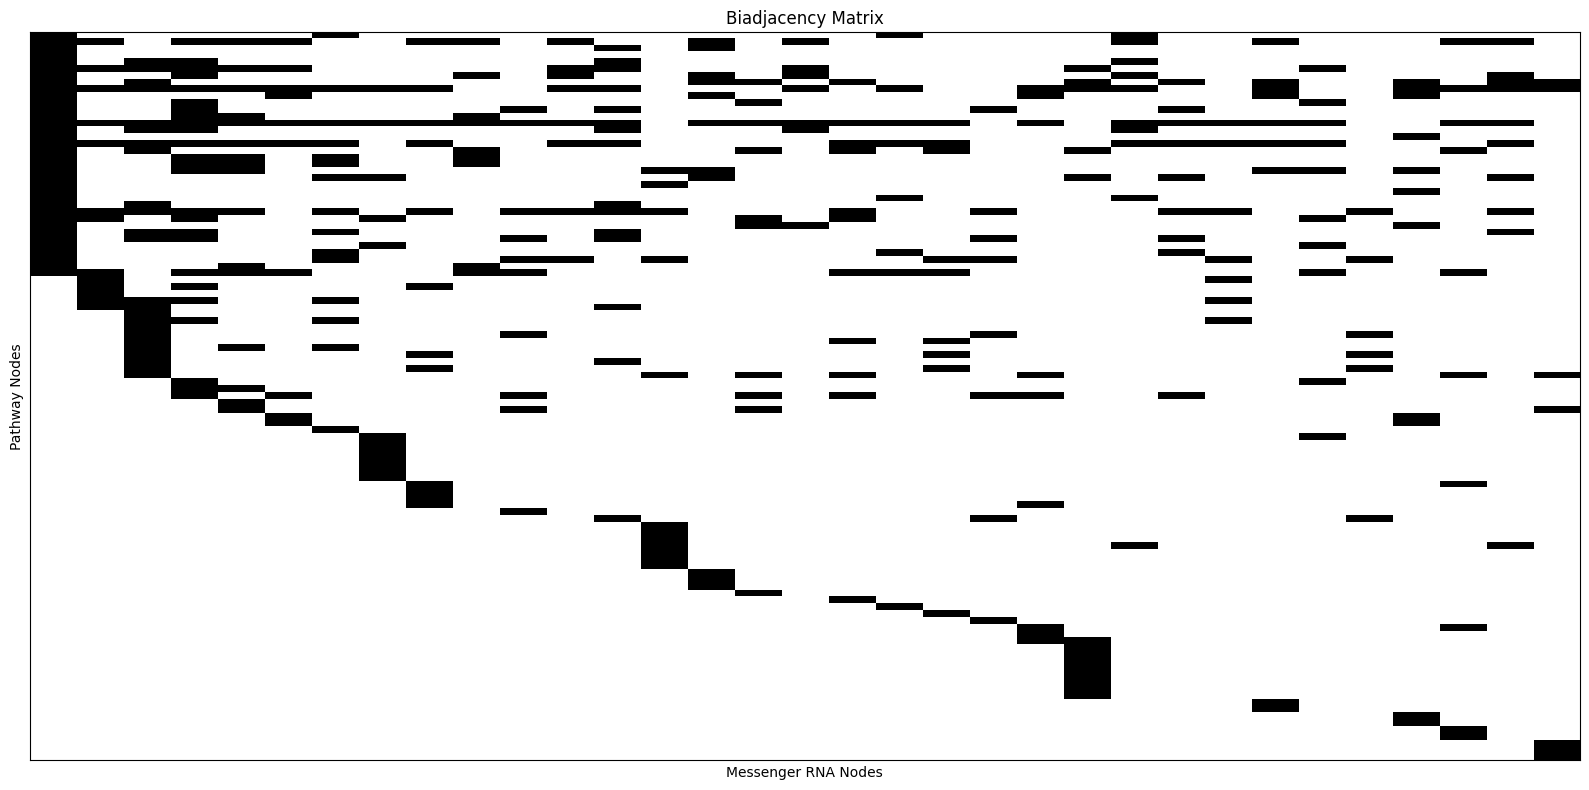

In [42]:
# Print the global network analysis report
global_report(df_edges, df_nodes)

In [43]:
# Print the analysis report for one of the network partitions
partition_report('Messenger RNA', df_nodes)

===== Messenger RNAs =====

> number of nodes = 107
> number of nodes in the largest component = 107 (100.0%)

##### Betweenness Centrality #####

> descriptive statistics: 
       betweenness_centrality
count              107.000000
mean                 0.008101
std                  0.025306
min                  0.000000
25%                  0.000000
50%                  0.000369
75%                  0.002710
max                  0.173773

> top-5 nodes in descending order: 
     label  betweenness_centrality
0     NAV1                0.173773
1     NFIX                0.160989
2      ERG                0.078393
3    CALN1                0.053782
4  RUNX1T1                0.048022

> bottom-5 nodes in descending order: 
      label  betweenness_centrality
102   ABHD5                     0.0
103  STRADB                     0.0
104   ATXN1                     0.0
105   TBX15                     0.0
106   KCNJ2                     0.0

##### Closeness Centrality #####

> descriptive stat

In [44]:
# Print the analysis report for one of the network partitions
partition_report('Pathway', df_nodes)

===== Pathways =====

> number of nodes = 33
> number of nodes in the largest component = 33 (100.0%)

##### Betweenness Centrality #####

> descriptive statistics: 
       betweenness_centrality
count               33.000000
mean                 0.042039
std                  0.038411
min                  0.004420
25%                  0.018544
50%                  0.033202
75%                  0.046665
max                  0.179010

> top-5 nodes in descending order: 
                                               label  betweenness_centrality
0                                 Pathways in cancer                0.179010
1                                        Endocytosis                0.120089
2                             MAPK signaling pathway                0.104585
3  Signaling pathways regulating pluripotency of ...                0.093956
4                              Wnt signaling pathway                0.090729

> bottom-5 nodes in descending order: 
                     labe

# Normal

In [45]:
# Define the group name
group = 'normal'

## Interaction Network

In [46]:
# Define the network type and the DataFrames associated with it
network_type = 'interaction'
df_edges = analyzed_networks[network_type]['edges'] \
    .query('group == @group')
df_nodes = analyzed_networks[network_type]['nodes'] \
    .query('group == @group')

> number of edges = 5072

> number of nodes (2915):
- MicroRNAs = 166 (5.69%)
- Messenger RNAs = 2749 (94.31%)

> network density = 0.01

> number of connected components = 14
> number of nodes in the largest component = 2873 (98.56%)

> nodes per module: 
    module_id  count
0         0.0   2719
1         1.0    164
2         2.0      2
3         3.0      2
4         4.0      2
5         5.0      2
6         6.0      2
7         7.0      2
8         8.0      2
9         9.0      2
10       10.0      2
11       11.0      2
12       12.0      2
13       13.0      2
14       14.0      2
15       15.0      2
16       16.0      2
17       17.0      2


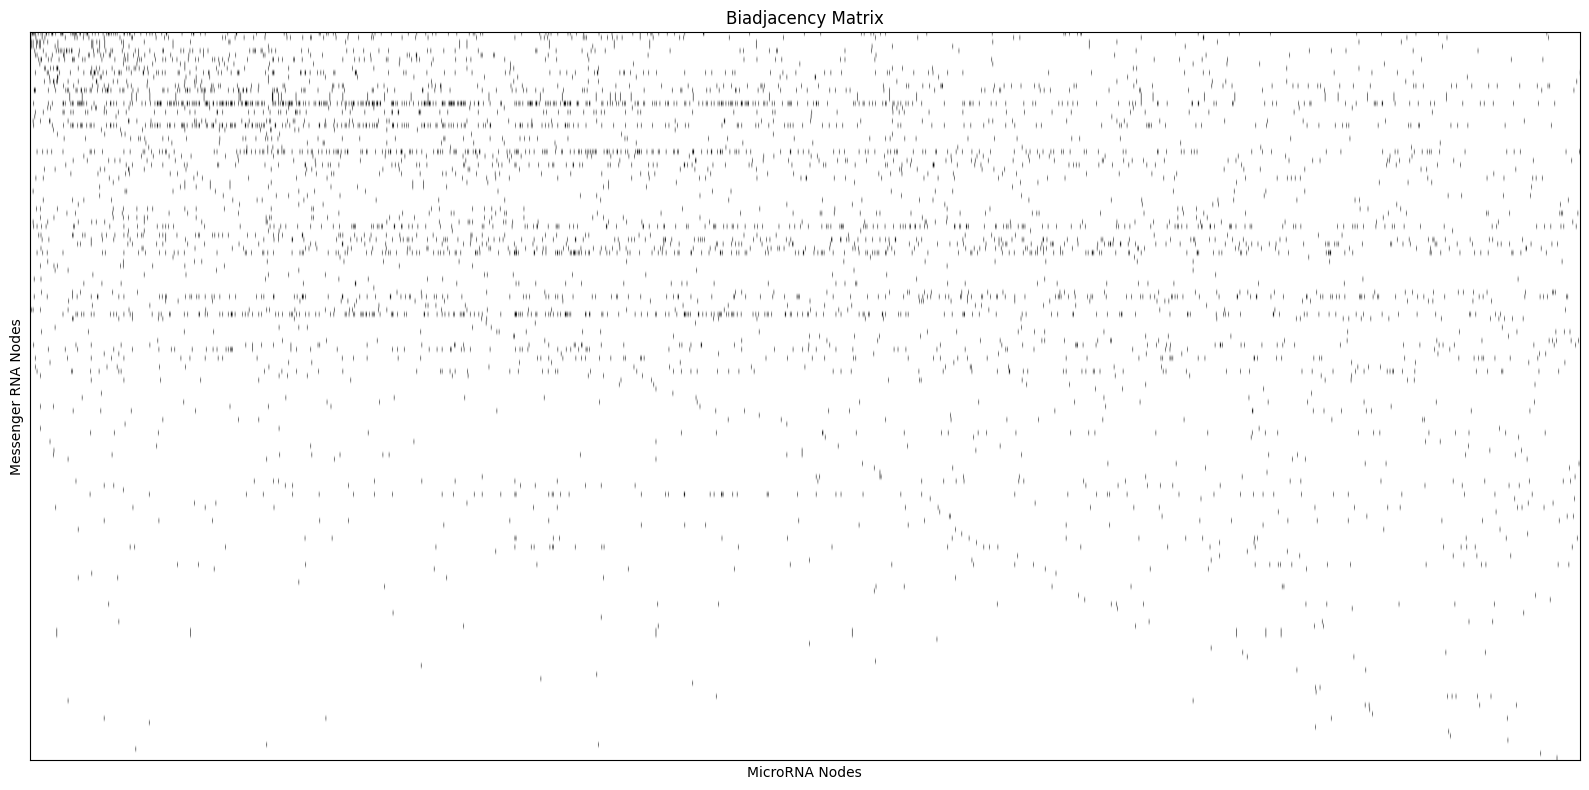

In [47]:
# Print the global network analysis report
global_report(df_edges, df_nodes)

In [48]:
# Print the analysis report for one of the network partitions
partition_report('MicroRNA', df_nodes)

===== MicroRNAs =====

> number of nodes = 166
> number of nodes in the largest component = 152 (91.57%)

##### Betweenness Centrality #####

> descriptive statistics: 
       betweenness_centrality
count              152.000000
mean                 0.016821
std                  0.032937
min                  0.000000
25%                  0.001429
50%                  0.004789
75%                  0.015310
max                  0.222570

> top-5 nodes in descending order: 
            label  betweenness_centrality
0   hsa-let-7d-5p                0.222570
1  hsa-miR-20b-5p                0.182494
2  hsa-miR-30e-5p                0.172102
3  hsa-miR-15a-5p                0.113808
4   hsa-miR-24-3p                0.096287

> bottom-5 nodes in descending order: 
               label  betweenness_centrality
147    hsa-let-7f-5p                     0.0
148   hsa-miR-503-5p                     0.0
149  hsa-miR-374c-5p                     0.0
150   hsa-miR-874-3p                     0.0
151   h

In [49]:
# Print the analysis report for one of the network partitions
partition_report('Messenger RNA', df_nodes)

===== Messenger RNAs =====

> number of nodes = 2749
> number of nodes in the largest component = 2721 (98.98%)

##### Betweenness Centrality #####

> descriptive statistics: 
       betweenness_centrality
count             2721.000000
mean                 0.000615
std                  0.004425
min                  0.000000
25%                  0.000000
50%                  0.000000
75%                  0.000274
max                  0.177904

> top-5 nodes in descending order: 
     label  betweenness_centrality
0  CCDC71L                0.177904
1   KCNJ15                0.086513
2   NFATC2                0.060283
3  DCUN1D3                0.052085
4     BNC2                0.033420

> bottom-5 nodes in descending order: 
       label  betweenness_centrality
2716  PTP4A1                     0.0
2717   KIF3A                     0.0
2718   SNIP1                     0.0
2719  CHST14                     0.0
2720    GRK3                     0.0

##### Closeness Centrality #####

> descript

## Membership Network

In [50]:
# Define the network type and the DataFrames associated with it
network_type = 'membership'
df_edges = analyzed_networks[network_type]['edges'] \
    .query('group == @group')
df_nodes = analyzed_networks[network_type]['nodes'] \
    .query('group == @group')

> number of edges = 3871

> number of nodes (952):
- Messenger RNAs = 835 (87.71%)
- Pathways = 117 (12.29%)

> network density = 0.04

> number of connected components = 1
> number of nodes in the largest component = 952 (100.0%)

> nodes per module: 
    module_id  count
0         0.0    867
1         1.0     52
2         2.0      2
3         3.0      2
4         4.0      2
5         5.0      2
6         6.0      2
7         7.0      2
8         8.0      2
9         9.0      2
10       10.0      2
11       11.0      2
12       12.0      2
13       13.0      2
14       14.0      2
15       15.0      2
16       16.0      2
17       17.0      2
18       18.0      1


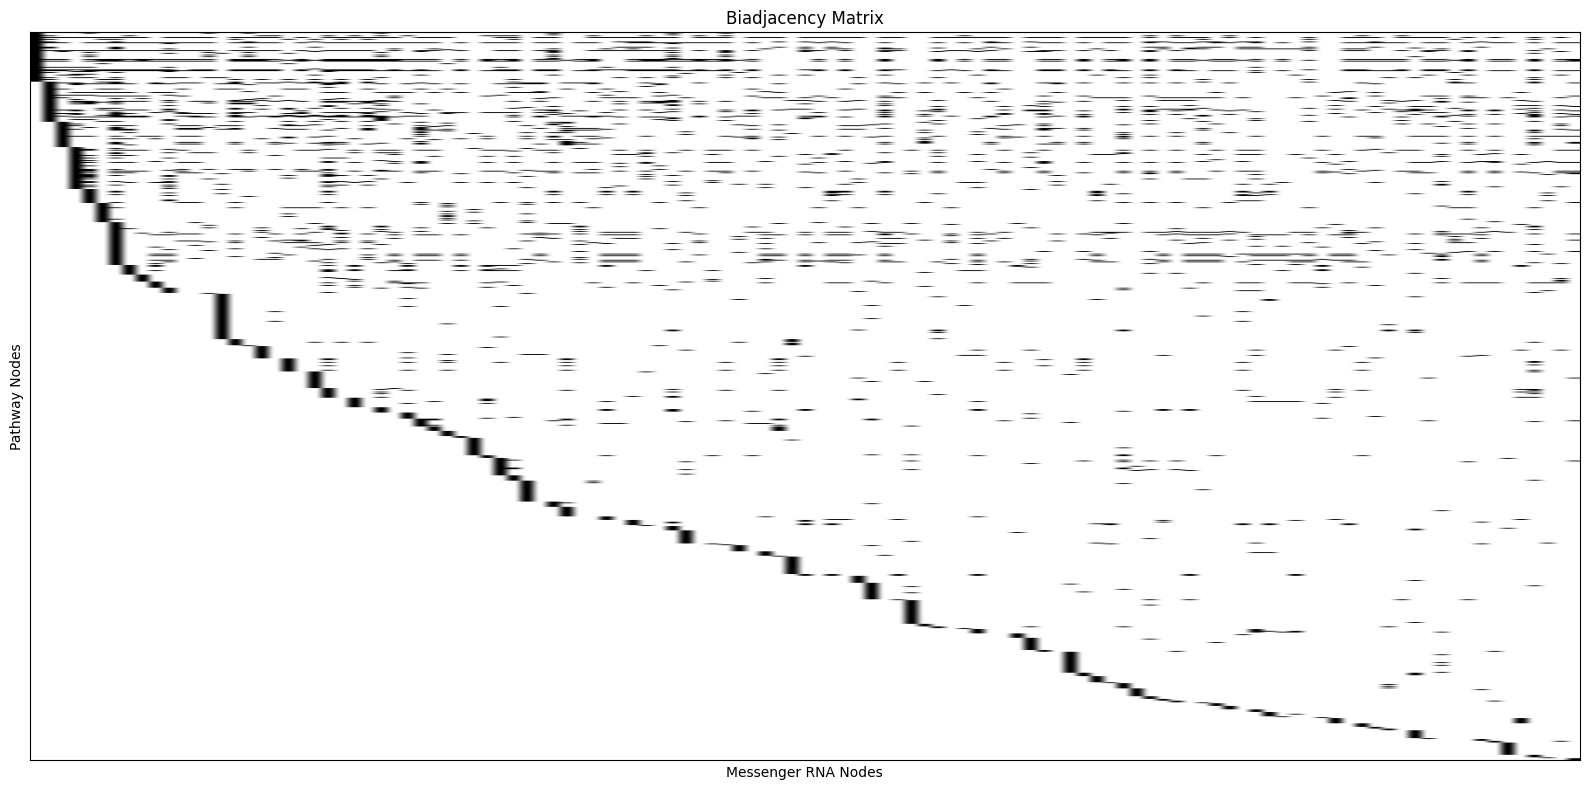

In [51]:
# Print the global network analysis report
global_report(df_edges, df_nodes)

In [52]:
# Print the analysis report for one of the network partitions
partition_report('Messenger RNA', df_nodes)

===== Messenger RNAs =====

> number of nodes = 835
> number of nodes in the largest component = 835 (100.0%)

##### Betweenness Centrality #####

> descriptive statistics: 
       betweenness_centrality
count              835.000000
mean                 0.001299
std                  0.005040
min                  0.000000
25%                  0.000000
50%                  0.000000
75%                  0.000324
max                  0.069125

> top-5 nodes in descending order: 
      label  betweenness_centrality
0   LDLRAD3                0.069125
1     ZC3H6                0.043758
2  KIAA0232                0.043758
3     UEVLD                0.043758
4   TSPOAP1                0.043758

> bottom-5 nodes in descending order: 
       label  betweenness_centrality
830  DENND1A                     0.0
831      SET                     0.0
832    ACTR3                     0.0
833    VDAC1                     0.0
834    PDCD4                     0.0

##### Closeness Centrality #####

> desc

In [53]:
# Print the analysis report for one of the network partitions
partition_report('Pathway', df_nodes)

===== Pathways =====

> number of nodes = 117
> number of nodes in the largest component = 117 (100.0%)

##### Betweenness Centrality #####

> descriptive statistics: 
       betweenness_centrality
count              117.000000
mean                 0.015664
std                  0.015751
min                  0.000762
25%                  0.004396
50%                  0.009475
75%                  0.022556
max                  0.082558

> top-5 nodes in descending order: 
                                         label  betweenness_centrality
0                                  Endocytosis                0.082558
1                           Pathways in cancer                0.069625
2  Protein processing in endoplasmic reticulum                0.057353
3                                Axon guidance                0.055015
4      Transcriptional misregulation in cancer                0.048666

> bottom-5 nodes in descending order: 
                               label  betweenness_centralit